In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor

np.random.seed(42)

In [7]:
# Input
X = np.linspace(0, 10, 100).reshape(-1, 1)

# True function + noise
y = np.sin(X).ravel() + np.random.normal(0, 0.15, 100)

print(X.shape, y.shape)

(100, 1) (100,)


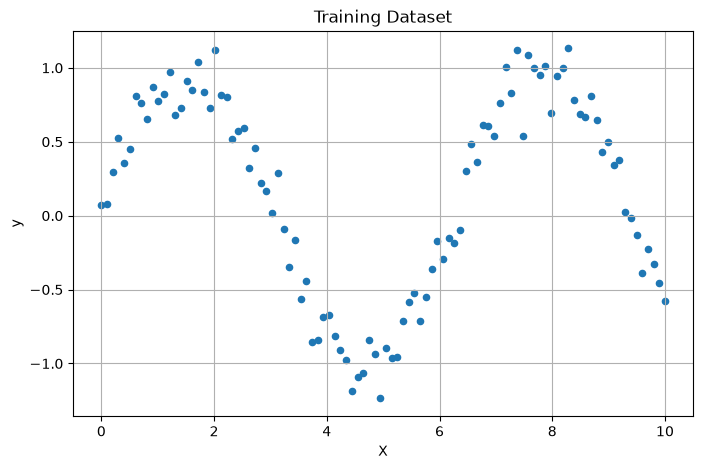

In [8]:
plt.figure(figsize=(8,5))

plt.scatter(X, y, s=20)

plt.title("Training Dataset")
plt.xlabel("X")
plt.ylabel("y")

plt.grid(True)
plt.show()

In [9]:
tree1 = DecisionTreeRegressor(max_depth= 2)

tree1.fit(X,y)

pred1 = tree1.predict(X)

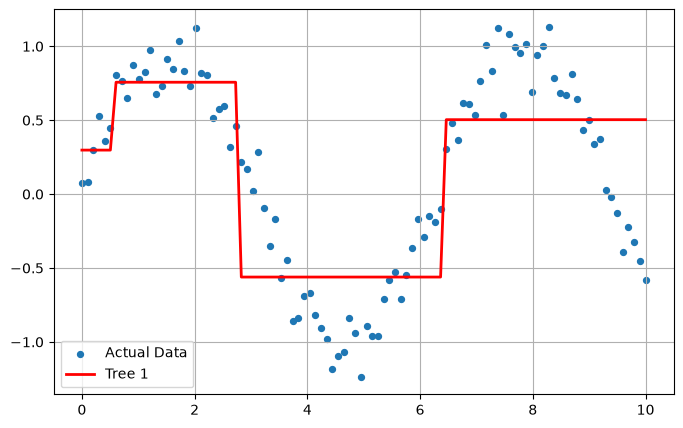

In [10]:
plt.figure(figsize=(8,5))

plt.scatter(X, y, s=18, label="Actual Data")

plt.plot(
    X,
    pred1,
    color="red",
    linewidth=2,
    label="Tree 1"
)

plt.legend()
plt.grid(True)
plt.show()

In [11]:
residual1 = y - pred1

print(residual1[:10])

[-2.23163047e-01 -2.17571395e-01  1.31967068e-04  2.29198113e-01
  6.03434358e-02  1.51060927e-01  4.97573906e-02  7.96608429e-03
 -1.04217235e-01  1.13570831e-01]


In [13]:
tree2 = DecisionTreeRegressor(max_depth=2)

tree2.fit(X, residual1)

pred2 = tree2.predict(X)

In [14]:
learning_rate = 0.1

prediction = pred1 + learning_rate * pred2

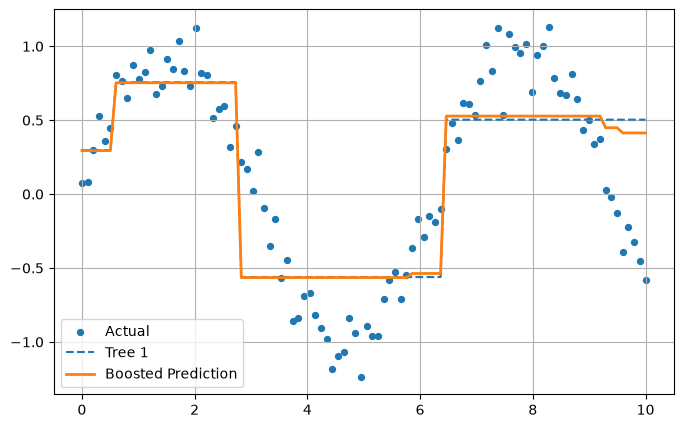

In [15]:
plt.figure(figsize=(8,5))

plt.scatter(X, y, s=18, label="Actual")

plt.plot(
    X,
    pred1,
    "--",
    label="Tree 1"
)

plt.plot(
    X,
    prediction,
    linewidth=2,
    label="Boosted Prediction"
)

plt.legend()
plt.grid(True)
plt.show()

In [16]:
class GradientBoosting:

    def __init__(self, n_estimators=50, learning_rate=0.1, max_depth=2):

        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth

        self.trees = []

    def fit(self, X, y):

        prediction = np.zeros(len(y))

        for _ in range(self.n_estimators):

            residual = y - prediction

            tree = DecisionTreeRegressor(max_depth=self.max_depth)

            tree.fit(X, residual)

            update = tree.predict(X)

            prediction += self.learning_rate * update

            self.trees.append(tree)

    def predict(self, X):

        prediction = np.zeros(len(X))

        for tree in self.trees:

            prediction += ( self.learning_rate * tree.predict(X))

        return prediction

In [17]:
model = GradientBoosting(n_estimators=100,learning_rate=0.1,max_depth=2)

model.fit(X,y)

y_pred = model.predict(X)

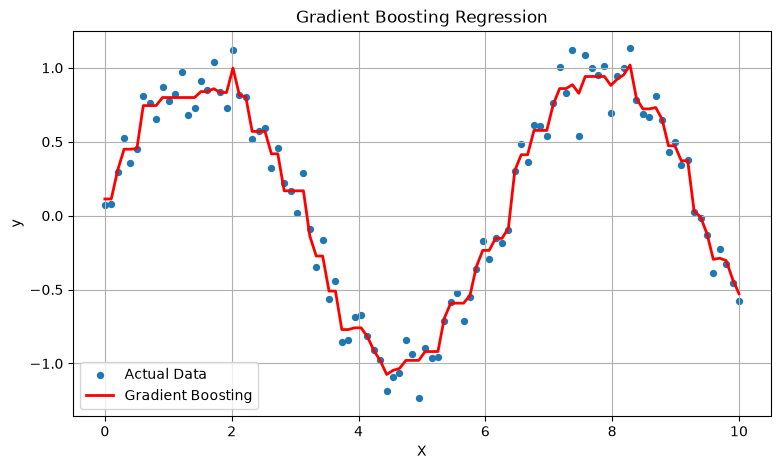

In [18]:
plt.figure(figsize=(9,5))

plt.scatter(
    X,
    y,
    s=18,
    label="Actual Data"
)

plt.plot(
    X,
    y_pred,
    color="red",
    linewidth=2,
    label="Gradient Boosting"
)

plt.title("Gradient Boosting Regression")

plt.xlabel("X")
plt.ylabel("y")

plt.legend()
plt.grid(True)
plt.show()